> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 4: Data Understanding

## Outline

- Load and preview a real-world dataset
- Inspect structure and identify data quality issues, such as missing or unusual data
- Perform basic grouped summaries to see trends

We are focused on the data understanding phase in business analytics.  The tasks in this labe will help you figure out what the data actually contains before you start making decisions or building models. By exploring the dataset, you can identify key details such as the meaning of each column, the types of data (numeric, categorical, etc.), the presence of missing or inconsistent values, and the overall size and structure of the data. It’s also important to look for patterns, unusual values, or outliers that could affect your analysis. Taking the time to understand your data early helps prevent mistakes, ensures your analysis is accurate, and guides you toward asking the right questions.


<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_04_data_understanding.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## SF Rentals - Business Context

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (price) can be compared with property features like size (sqft), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (nhood, lat, lon) allows for geographic analysis of rent differences across neighborhoods; and time variables (date, year) help track how the market changes over time. Text fields like title and descr can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing.

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from [Github](https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip).

## Data Dictionary

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     |  Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1). |
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data

### Instructions:
- Import the `pandas` library.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

### Note on importing data:
- In this lab we will be importing data from a website, rather than a Python library
- A "CSV" file is a text file that has commma separated values.  You can open the file in Excel, Pandas, or in a notepad on your laptop.
- GitHub can host text files as well as code.  In this case we are pulling the data directly from GitHub into a dataframe.

In [11]:
import pandas as pd

url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  object 
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8015 non-null    object 
dtypes: float64(8), object(9)
memory usage: 26.0+ MB


/tmp/ipykernel_8407/2808982895.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [12]:
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


### 🔧 Do the following – Part 1

1. Add one line of code to print the number of rows and columns.

In [13]:
# Add code here 🔧
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Rows: 200810 Columns: 17


## 2. Inspecting the Data

### Instructions:
- Identify missing values.
- Check data types are correct(e.g., dates, numeric columns).
- Check for outliers key numeric variables like `price`, `sqft`, `beds`, or `baths`. The concept of outliers will be covered more in week 6.  This week we will do only a very basic filter for outlier values.   

### Think about:
- Are there missing values?
- Do the data types look appropriate?

In [14]:
# Check for missing values
df.isnull().sum()

,0
post_id,0
date,13
year,14
nhood,14
city,14
county,1408
price,14
beds,6622
baths,158135
sqft,136131


In [15]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


In [16]:
# Check data types
df.dtypes

,0
post_id,object
date,object
year,float64
nhood,object
city,object
county,object
price,float64
beds,float64
baths,float64
sqft,float64


### 🔧 Do the following – Part 2

1. Use `.describe()` to inspect the **square footage (`sqft`)** by itself.

In [17]:
# Add code here 🔧
df['sqft'].describe()

,sqft
count,64679.000000
mean,1201.827688
std,5000.217864
min,80.000000
25%,750.000000
50%,1000.000000
75%,1360.000000
max,900000.000000


### Reflection:
2.1. What patterns or issues do you see with square footage values? Is there anything unusual?


### ✍️ Your Response: 🔧
2.1. Only 64,679 of the 200,810 listings contain a square footage value, so most of the dataset is missing this information. The typical values appear reasonable, with a median of 1,000 square feet and the middle 50 percent ranging from 750 to 1,360 square feet. However, the maximum is 900,000 square feet, which is clearly unusual for a rental listing and is likely an error. This extreme value also helps explain why the standard deviation is much larger than the median. The minimum of 80 square feet is also unusually small and should be investigated.


## 3. Basic Exploration

Use `groupby` and `value_counts` to summarize trends across neighborhoods and cities.  The concept of data exploration will be covered more in week 5.


In [18]:
# Average price by neighborhood
df.groupby('nhood')['price'].mean().sort_values(ascending=False).head(10)

,price
nhood,
inverness,5310.000000
atherton,4536.010989
tiburon / belvedere,4265.346591
financial district,3958.161417
west portal / forest hills,3827.276119
saratoga,3801.850900
kentfield / ross,3611.577855
los altos,3605.047072
SOMA / south beach,3585.900793


In [19]:
# Top cities by count
df['city'].value_counts().head(10)

,count
city,
san francisco,55730
san jose,13733
oakland,9443
santa rosa,6230
santa cruz,5464
san mateo,5127
sunnyvale,4526
mountain view,4414
berkeley,4201


### 🔧 Do the following – Part 3

Seek to understand the data by performing the following:

1. Group the listings by `year` and calculate the average price for each year.  Sort the results by year.
2. Create a line chart to show the average price by year (from step 1)
2. Use `.value_counts()` on the `room_in_apt` column to see how common room rentals are.

year
2000.0    1418.695652
2001.0    2070.038095
2002.0    1709.347079
2003.0    1587.705745
2004.0    1640.209812
2005.0    1525.475233
2006.0    1822.992589
2007.0    2152.303178
2008.0    2067.772489
2009.0    1951.866827
2010.0    1831.296377
2011.0    2082.872963
2012.0    2126.308527
2013.0    2679.816015
2014.0    2799.560424
2015.0    3016.057967
2016.0    2892.953247
2017.0    2998.658354
2018.0    2967.051076
Name: price, dtype: float64


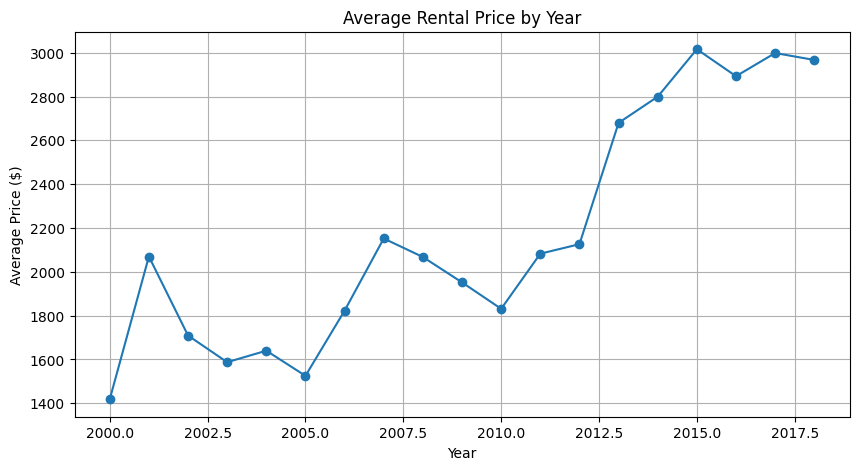

,count
room_in_apt,
0.0,200511
1.0,285


In [20]:
# Add code here 🔧
import matplotlib.pyplot as plt

average_price_by_year = df.groupby('year')['price'].mean().sort_index()

print(average_price_by_year)

plt.figure(figsize=(10, 5))
plt.plot(average_price_by_year.index, average_price_by_year.values, marker='o')
plt.title('Average Rental Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price ($)')
plt.grid(True)
plt.show()

df['room_in_apt'].value_counts()

## 4. Reflection:

4.1. Explain, in detail, any trends you see with year and room_in_apt.

4.2. What would be the right way to handle missing data in several of the variables?  Are those variables usable and useful?

### ✍️ Your Response: 🔧
4.1. The average rental price changes considerably over time but shows an overall upward trend. Average price was about $1,419 in 2000 and generally remained below $2,200 through 2012. It increased sharply to about $2,680 in 2013, reached about $3,016 in 2015, and then remained close to $3,000 through 2018. The room_in_apt counts show that 200,511 listings are for entire units, while only 285 are room rentals. This means room rentals make up only about 0.14 percent of the available listings, so this dataset mainly represents entire apartments and homes.


4.2. The best treatment depends on the variable and the purpose of the analysis. Rows missing essential fields such as year or price could be removed because only 14 rows are affected. Missing numeric values such as square footage, bedrooms, and bathrooms should not automatically be replaced with zero because zero would have a different meaning. Those variables could be analyzed using the available observations, or a reasonable imputation method could be used if the missing values are understood. Square footage and bathrooms may still be useful, but their large amount of missing data limits how confidently the results can be applied to the full dataset. Address, latitude, longitude, description, and details are missing for most listings, so they would probably need to be excluded unless the analysis specifically required them.


## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [21]:
!jupyter nbconvert --to html "lab_04_data_understanding.ipynb"

[NbConvertApp] WARNING | pattern 'lab_04_data_understanding.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]